In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("C:\\Users\\HP\\Downloads\\netflix_titles.csv")

In [3]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### 2. Data Cleaning:

#### Check for missing values and handle them appropriately.
#### Remove duplicate entries if any.
#### Correct any inconsistencies or errors in the data

In [4]:
data.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [40]:
data['date_added'] = pd.to_datetime(data['date_added'], format="mixed")

In [41]:
data['date_added']

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[ns]

In [6]:
numercial_cols = data.select_dtypes(include="number").columns.tolist()
numercial_cols

['release_year']

In [7]:
categorical_cols = data.select_dtypes(include="object").columns.tolist()
categorical_cols

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'rating',
 'duration',
 'listed_in',
 'description']

In [8]:
for col in categorical_cols:
    # print(col)
    print(data[col].isna().sum())
    if data[col].isna().sum() > 0:
        data[col] = data[col].fillna(value=data[col].mode()[0])

print("Null values are filled successfully!")
print(data.isna().sum())

0
0
0
2634
825
831
10
4
3
0
0
Null values are filled successfully!
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [9]:
data.duplicated().sum()

np.int64(0)

there is no duplicate record in the system, so we can move ahead!

## Exploratory Data Analysis:

**Compute basic descriptive statistics such as mean, median, mode, range, and standard deviation for relevant variables**

In [10]:
data.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [11]:
data['release_year'].mode()[0]

np.int64(2018)

In [12]:
print(data['release_year'].min())
print(data['release_year'].max())

1925
2021


In [13]:
data['release_year'].std()

8.819312130834057

1. Mean -> 8807.0
2. Median -> 2017.00
3. Mode -> 2018
4. Range -> [1925, 2021]
5. standard deviation -> 8.819312130834057

In [14]:
data.describe(include="object")

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,8807,8807,8807,8807,8807,8807,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,2653,844,3649,119,3211,1796,362,4


##### Create visualizations to represent the distribution of content over different genres

In [15]:
data.type.unique()

array(['Movie', 'TV Show'], dtype=object)

In [37]:
data.listed_in.nunique()

514

In [17]:
result = data.groupby('listed_in').size().reset_index().rename(columns={0:"counts"})
result = result.sort_values(by="counts", ascending=False)
result = result.head(7)

In [18]:
result

,listed_in,counts
326,"Dramas, International Movies",362
274,Documentaries,359
470,Stand-Up Comedy,334
200,"Comedies, Dramas, International Movies",274
319,"Dramas, Independent Movies, International Movies",252
422,Kids' TV,220
121,Children & Family Movies,215


In [19]:
import matplotlib.pyplot as plt


Text(0, 0.5, 'Frequency')

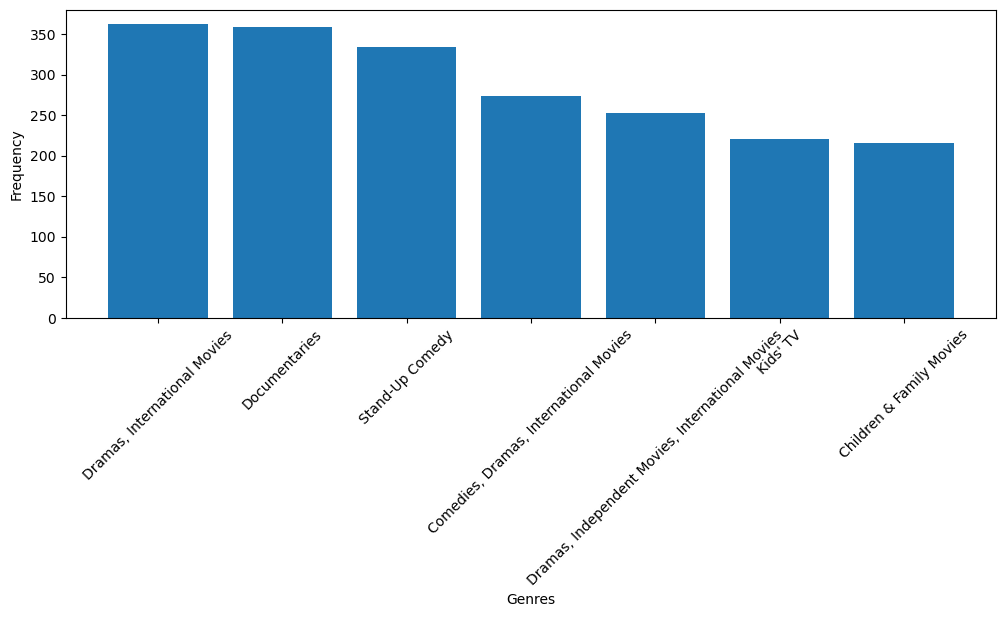

In [20]:
plt.figure(figsize=(12, 4))
plt.bar(result['listed_in'], result['counts'])
plt.xticks(rotation=45)
plt.xlabel("Genres")
plt.ylabel("Frequency")


#### insights:

1. Dramas, International Movies, and Documentaries, and Stand-up Comedy Movies are most supported by Netflix.

##### 2. Visualize the distribution of content across release years

In [21]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

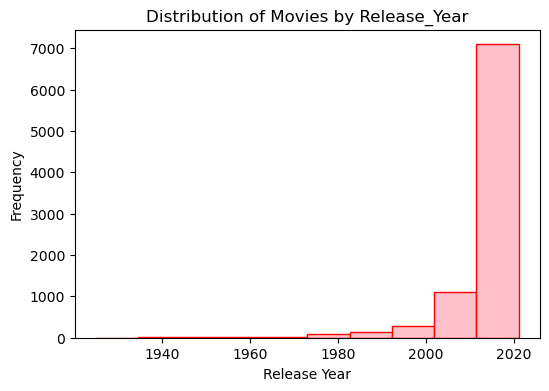

In [30]:
plt.figure(figsize=(6, 4))
plt.hist(data['release_year'], color="pink", edgecolor="red")
plt.title("Distribution of Movies by Release_Year")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

In [31]:
from scipy.stats import skew

skew(data['release_year'])

np.float64(-3.4459779968241837)

##### insights:

since 2010 to 2020, netflix relased highest number of movies, of above 7000.
while lowest number of films relased before 1980 , which measn, due to low accessibilty and affordability of internet over the countries.

##### 3. If there's a temporal component, perform time series analysis to identify trends and patterns over time

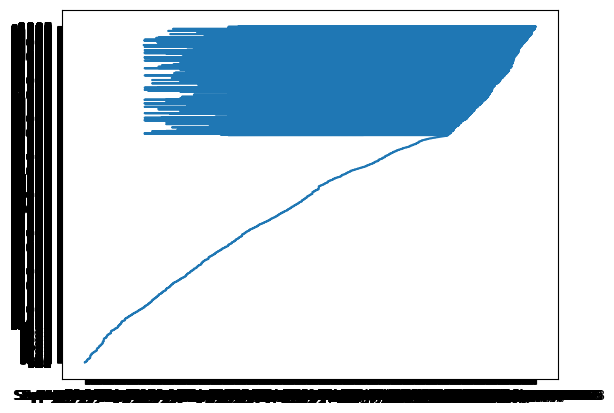

In [33]:
plt.plot(data['date_added'], data['show_id'])

In [42]:
result = data.groupby(['date_added']).size().reset_index().rename(columns={0:'counts'})
result = result.sort_values(by='date_added', ascending=True)
result

,date_added,counts
0,2008-01-01,1
1,2008-02-04,1
2,2009-05-05,1
3,2009-11-18,1
4,2010-11-01,1
...,...,...
1709,2021-09-21,5
1710,2021-09-22,9
1711,2021-09-23,2
1712,2021-09-24,10


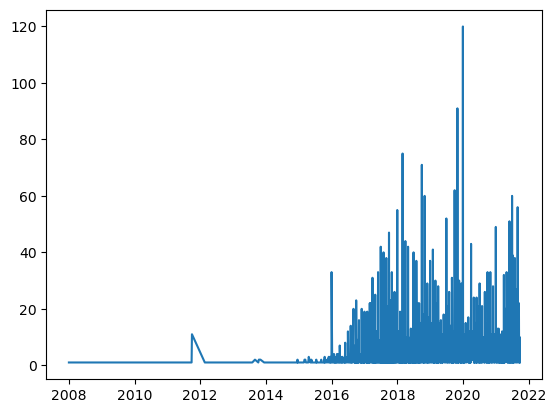

In [43]:
plt.plot(result['date_added'], result['counts'])

In [58]:
month_year = data['date_added'].dt.to_period('M')
# month_year
result_2 = data.groupby(month_year).agg(counts=("show_id", "count")).reset_index()
# result_2
result_2 = result_2.sort_values(by="date_added", ascending=True)
result_2

,date_added,counts
0,2008-01,1
1,2008-02,1
2,2009-05,1
3,2009-11,1
4,2010-11,1
...,...,...
103,2021-05,132
104,2021-06,207
105,2021-07,257
106,2021-08,178


<Axes: xlabel='date_added'>

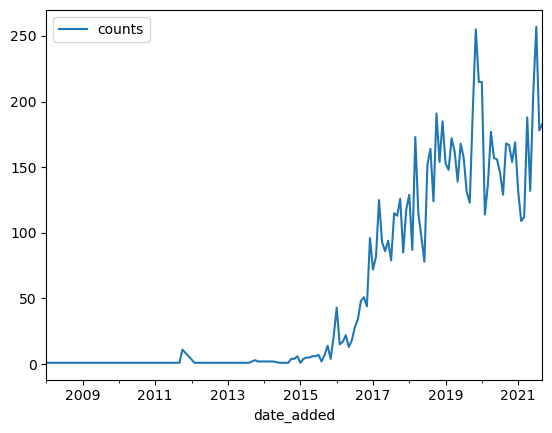

In [54]:
result_2.plot(kind="line", x='date_added', y='counts')

##### 6. Explore the length of movies or episodes and identify any trends

In [59]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [61]:
data.duration.nunique()

220

In [66]:
ans = data['duration'].value_counts().sort_values(ascending=False).reset_index()
ans

,duration,count
0,1 Season,1796
1,2 Seasons,425
2,3 Seasons,199
3,90 min,152
4,94 min,146
...,...,...
215,167 min,1
216,43 min,1
217,196 min,1
218,200 min,1
